<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da04_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터프레임 준비

In [2]:
tips = sns.load_dataset(name='tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# `matplotlib.pyplot` 모듈을 사용한 데이터 시각화

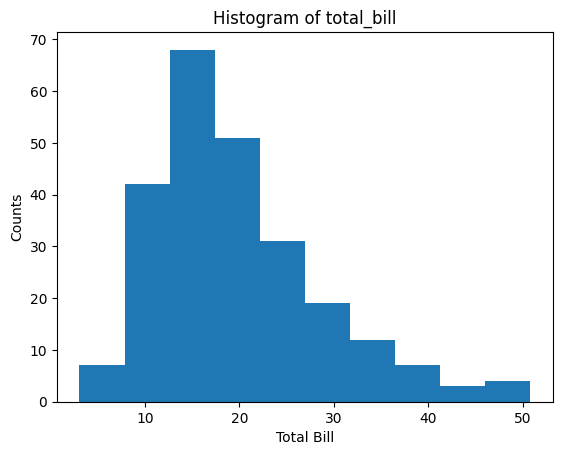

In [5]:
# 1. Figure 객체 생성.
fig = plt.figure()

# 2. Figure 객체에 Axes 설정(Subplot 설정).
# axis = fig.add_subplot(1, 1, 1)  # fig.add_subplot(nrows, ncols, index)
axis = fig.add_subplot(111)  # fig.add_subplot(pos): 행/열/인덱스 순서로 만들어진 3자리 정수

# 3. Axes에 그래프를 그림.
axis.hist(x=tips.total_bill)  # 히스토그램

# 4. 그래프의 옵션들 설정.
axis.set_title('Histogram of total_bill')
axis.set_xlabel('Total Bill')
axis.set_ylabel('Counts')

# 5. 그래프 보여주기.
plt.show()

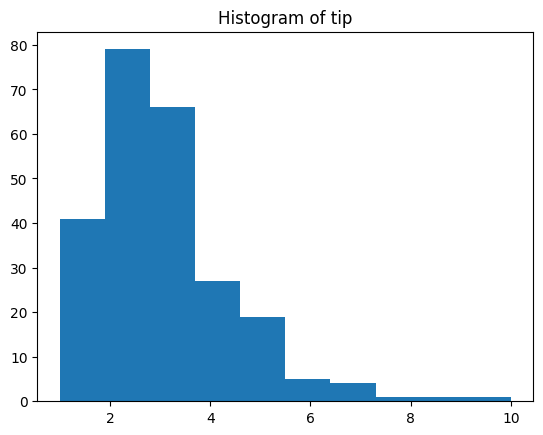

In [6]:
# 1. Figure, Axes 객체 생성.
fig, axis = plt.subplots()  # nrows=1, ncols=1 (default argument)

# 2. 그래프 그림.
axis.hist(x=tips.tip)

# 3. 옵션 설정.
axis.set_title('Histogram of tip')

# 4. 그래프 보여주기.
plt.show()

1개의 Figure에 1개의 Axis(Subplot)만 있는 경우에는, `matplotlib.pyplot` 모듈의 top-level 함수를 사용해서 간단히 그래프를 그릴 수 있음.

top-level 함수를 사용하면, Figure 또는 Axes 객체를 생성하는 코드를 명시적으로 작성할 필요가 없음.

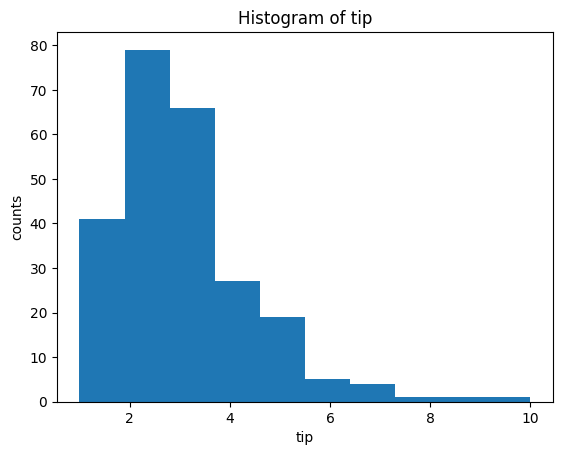

In [7]:
# Figure 생성 -> Axes 생성 -> 히스토그램 그리기.
plt.hist(x=tips.tip)

# 그래프 옵션
plt.title('Histogram of tip')
plt.xlabel('tip')
plt.ylabel('counts')

plt.show()

# Box Plot(상자 그림)

연속형 자료(숫자 타입 데이터)의 기술 통계량(최솟값, 1사분위값, 중앙값, 3사분위값, 최댓값)과 이상치(outliers)를 상자 모양으로 시각화한 그래프.

In [8]:
tips.total_bill.describe()

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


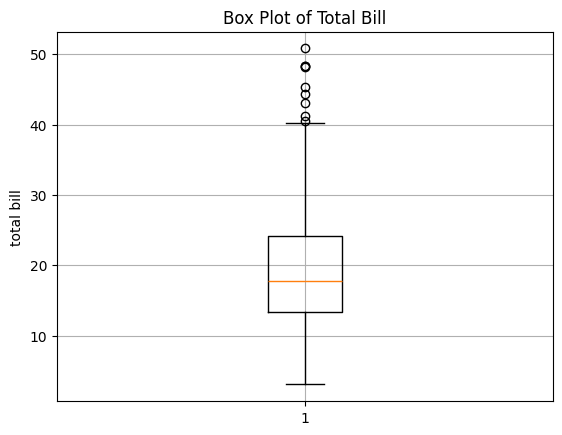

In [9]:
# 영수증 금액의 상자 그림
plt.boxplot(x=tips.total_bill)
plt.title('Box Plot of Total Bill')
plt.ylabel('total bill')
plt.grid()
plt.show()

IQR(inter-quartile range): 3사분위(75%)값 - 1사분위(25%)값

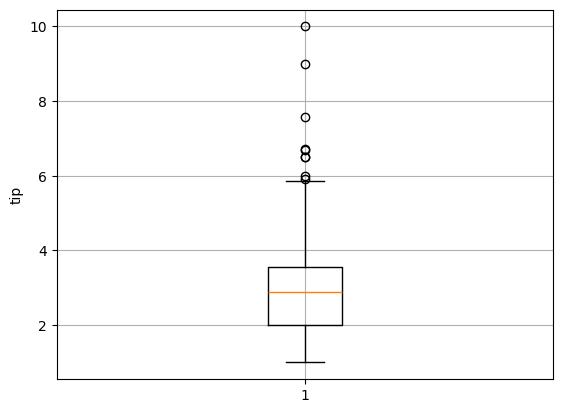

In [10]:
# 팁의 box plot
plt.boxplot(x=tips.tip)
plt.ylabel('tip')
plt.grid()
plt.show()

In [11]:
tips.tip.describe()

,tip
count,244.000000
mean,2.998279
std,1.383638
min,1.000000
25%,2.000000
50%,2.900000
75%,3.562500
max,10.000000


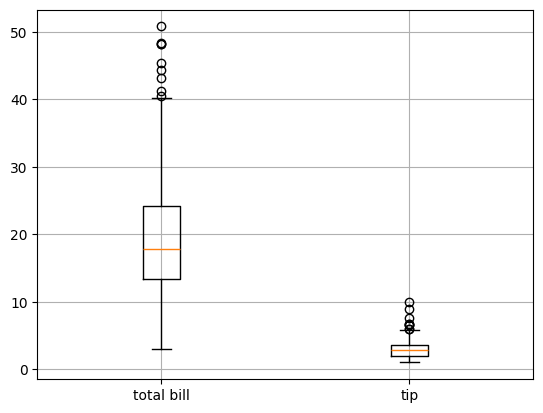

In [12]:
plt.boxplot(x=[tips.total_bill, tips.tip], tick_labels=['total bill', 'tip'])
plt.grid()
plt.show()

1개의 Figure 안에 2개의 Axes를 좌/우로 배치해서, 왼쪽에서 영수증 금액의 box plot을, 오른쪽에는 팁의 box plot을 시각화.

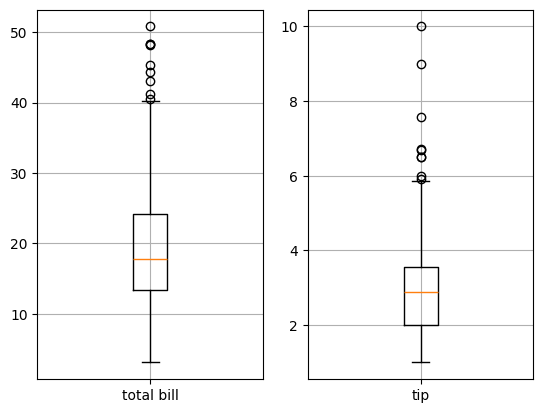

In [13]:
fig = plt.figure()  # Figure 객체 생성

ax1 = fig.add_subplot(1, 2, 1)  # 첫번째 Axes 객체 생성
ax2 = fig.add_subplot(122)  # 두번째 Axes 객체 생성

ax1.boxplot(x=tips.total_bill, tick_labels=['total bill'])  # 첫번째 축에 영수증 box plot
ax2.boxplot(x=tips.tip, tick_labels=['tip'])  # 두번째 축에 팁 box plot

ax1.grid()
ax2.grid()

plt.show()

[<Axes: > <Axes: >]
<class 'numpy.ndarray'>


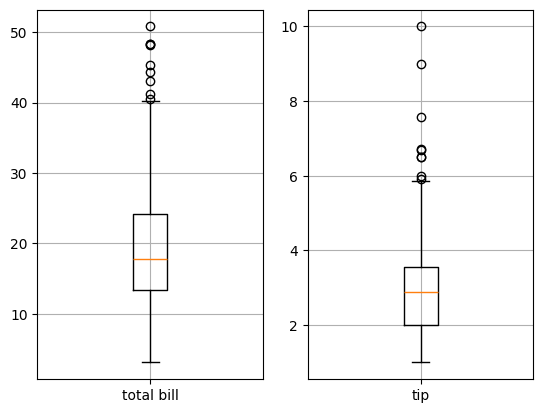

In [14]:
fig, axes = plt.subplots(ncols=2)

print(axes)  #> axes: Axes 클래스 객체들의 배열(numpy.ndarray)
print(type(axes))

axes[0].boxplot(x=tips.total_bill, tick_labels=['total bill'])
axes[0].grid()

axes[1].boxplot(x=tips.tip, tick_labels=['tip'])
axes[1].grid()

plt.show()

## 성별 팁의 box plot

*   남성의 팁의 기술 통계량 출력
*   여성의 팁의 기술 통계량 출력
*   1개의 Axes 안에 성별 팁의 box plot 2개를 시각화.

In [15]:
tips.sex.unique()

['Female', 'Male']
Categories (2, object): ['Male', 'Female']

In [16]:
# data_frame.category_column.cat.categories
# cat: CatergoricalAccessor(카테고리 타입 접근자)
tips.sex.cat.categories

Index(['Male', 'Female'], dtype='object')

In [17]:
for x in tips.sex.cat.categories:
    print(x)

Male
Female


In [18]:
tip_male = tips[tips.sex == 'Male'].tip
tip_male

,tip
1,1.66
2,3.50
3,3.31
5,4.71
6,2.00
...,...
236,1.00
237,1.17
239,5.92
241,2.00


In [19]:
tip_male.describe()  # 남성 팁의 기술 통계량

,tip
count,157.000000
mean,3.089618
std,1.489102
min,1.000000
25%,2.000000
50%,3.000000
75%,3.760000
max,10.000000


In [20]:
tip_female = tips[tips.sex == 'Female'].tip
tip_female.describe()  # 여성 팁 기술 통계량

,tip
count,87.000000
mean,2.833448
std,1.159495
min,1.000000
25%,2.000000
50%,2.750000
75%,3.500000
max,6.500000


In [21]:
tips.groupby(by='sex', observed=True).tip.describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Male,157.0,3.089618,1.489102,1.0,2.0,3.00,3.76,10.0
Female,87.0,2.833448,1.159495,1.0,2.0,2.75,3.50,6.5


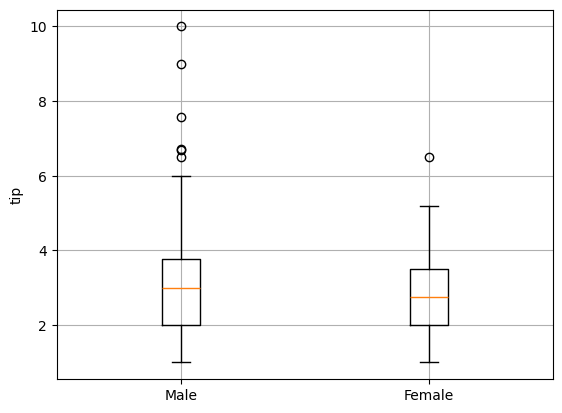

In [22]:
plt.boxplot(x=[tip_male, tip_female],
            tick_labels=tips.sex.cat.categories)
plt.ylabel('tip')
plt.grid()
plt.show()

## 시간별 팁의 box plot

In [23]:
tips.time.cat.categories

Index(['Lunch', 'Dinner'], dtype='object')

In [24]:
tip_lunch = tips[tips.time == 'Lunch'].tip

In [25]:
tip_lunch.describe()

,tip
count,68.000000
mean,2.728088
std,1.205345
min,1.250000
25%,2.000000
50%,2.250000
75%,3.287500
max,6.700000


In [26]:
tip_dinner = tips[tips.time == 'Dinner'].tip

In [27]:
tip_dinner.describe()

,tip
count,176.000000
mean,3.102670
std,1.436243
min,1.000000
25%,2.000000
50%,3.000000
75%,3.687500
max,10.000000


In [28]:
tips.groupby(by='time', observed=True).tip.describe()

,count,mean,std,min,25%,50%,75%,max
time,,,,,,,,
Lunch,68.0,2.728088,1.205345,1.25,2.0,2.25,3.2875,6.7
Dinner,176.0,3.102670,1.436243,1.00,2.0,3.00,3.6875,10.0


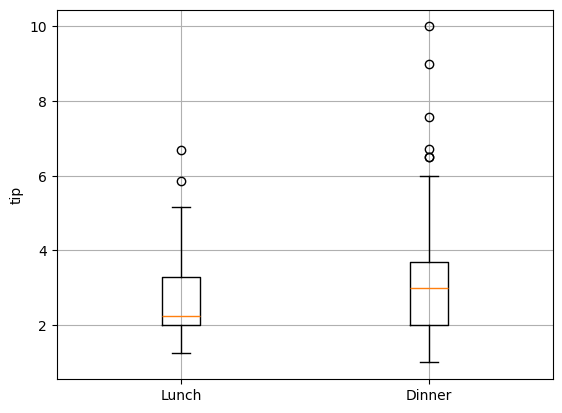

In [29]:
plt.boxplot(x=[tip_lunch, tip_dinner],
            tick_labels=tips.time.cat.categories)
plt.ylabel('tip')
plt.grid()
plt.show()

## 요일별 팁의 box plot

In [30]:
tips.groupby(by='day', observed=True).tip.describe()

,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
Thur,62.0,2.771452,1.240223,1.25,2.0000,2.305,3.3625,6.70
Fri,19.0,2.734737,1.019577,1.00,1.9600,3.000,3.3650,4.73
Sat,87.0,2.993103,1.631014,1.00,2.0000,2.750,3.3700,10.00
Sun,76.0,3.255132,1.234880,1.01,2.0375,3.150,4.0000,6.50


In [31]:
days = tips.day.cat.categories
days

Index(['Thur', 'Fri', 'Sat', 'Sun'], dtype='object')

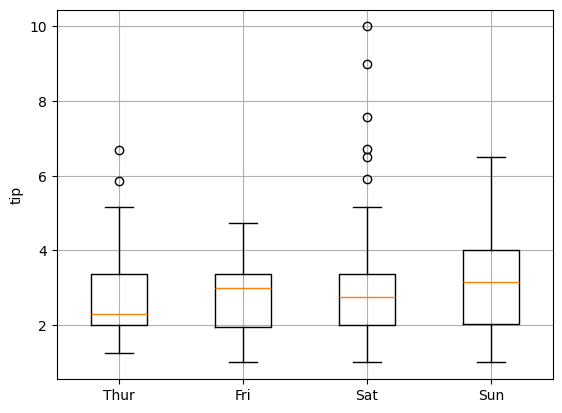

In [32]:
# Index 객체는 iterable --> for 반복문에서 사용.
# data = []  # 요일별 팁을 저장하기 위한 리스트.
# for d in days:
#     tip_by_day = tips[tips.day == d].tip
#     data.append(tip_by_day)
data = [ tips[tips.day == x].tip for x in days ]

plt.boxplot(x=data, tick_labels=days)
plt.ylabel('tip')
plt.grid()
plt.show()

# Histogram(히스토그램)

*   연속형 자료(숫자 타입 데이터)를 구간으로 나눠서 그 구간 안에 포함된 자료의 개수를 막대 형태로 표현한 그래프.
*   데이터의 분포, 치우침을 파악할 수 있음.
*   skewness(왜도): 데이터의 비대칭성(한쪽으로 얼마나 치우쳐 있는 지 정도)을 나타내는 통계량.
    *   skewness > 0 (양의 왜도)
        *   데이터가 왼쪽으로 치우쳐 있는 경우.
        *   오른쪽으로 긴 꼬리를 갖는 경우.
        *   최빈값 < 중앙값(median) < 평균(mean)
    *   skewness = 0 (대칭 분포)
        *   좌우대칭. (예) 표준정규분포
        *   최빈값 = 중앙값 = 평균
    *   skewness < 0 (음의 왜도)
        *   왼쪽으로 긴 꼬리를 갖는 경우.
        *   데이터가 오른쪽으로 치우쳐 있는 경우.
        *   평균 < 중앙값 < 최빈값


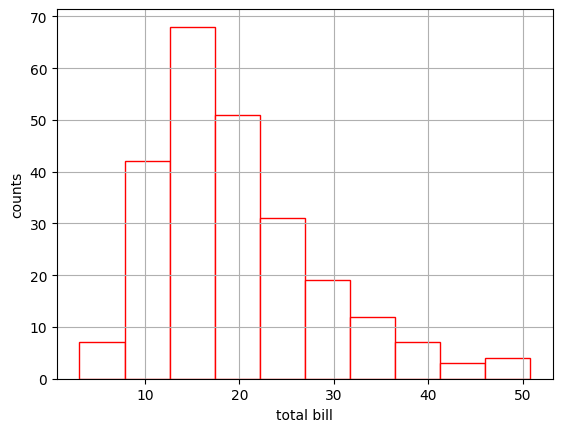

In [50]:
# 영수증 금액의 히스토그램
plt.hist(
    x=tips.total_bill,  # x: 히스토그램을 그리기 위한 연속형 자료(숫자 타입 컬럼)
    edgecolor='red',    # edgecolor: 막대 테두리 색깔
    color='white',      # color: 막대 내부를 채우는 색깔
    bins=10             # bins: 막대 개수 또는 구간.
)
plt.grid()
plt.xlabel('total bill')
plt.ylabel('counts')
plt.show()

In [40]:
tips.total_bill.describe()  #> 중앙값 < 평균

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


In [41]:
tips.total_bill.skew()  # 양의 왜도 --> 오른쪽으로 긴 꼬리 --> 왼쪽으로 치우침.

np.float64(1.1332130376158205)

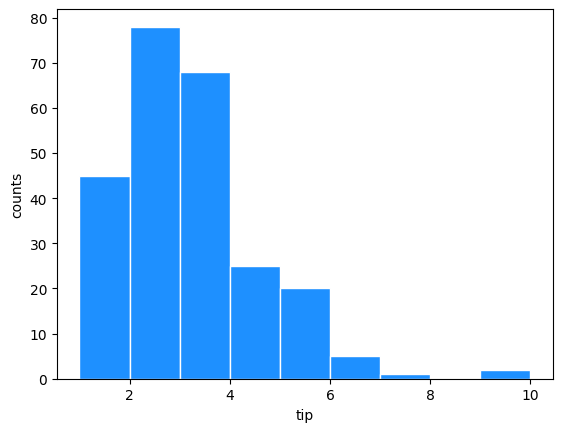

In [57]:
# tip 히스토그램
plt.hist(x=tips.tip, edgecolor='white', color='DodgerBlue',
         bins=np.arange(1, 11))
plt.xlabel('tip')
plt.ylabel('counts')
plt.show()

In [58]:
tips.tip.describe()  #> median < mean  --> 왼쪽으로 치우침 --> 오른쪽으로 꼬리가 길게.

,tip
count,244.000000
mean,2.998279
std,1.383638
min,1.000000
25%,2.000000
50%,2.900000
75%,3.562500
max,10.000000


In [59]:
tips.tip.skew()

np.float64(1.4654510370979401)

# 막대 그래프(Bar chart)

*   카테고리(범주) 타입 변수의 빈도수를 막대로 표현한 그래프.
*   연속형 변수의 카테고리별(그룹별) 통계량을 막대로 표현한 그래프.

## 세로 막대 그래프(vertical bar graph)

In [60]:
gender_counts = tips.sex.value_counts()
gender_counts

,count
sex,
Male,157
Female,87


In [61]:
gender_counts.index  # pandas.Series.index 속성

CategoricalIndex(['Male', 'Female'], categories=['Male', 'Female'], ordered=False, dtype='category', name='sex')

In [62]:
gender_counts.values  # pandas.Series.values 속성

array([157,  87])

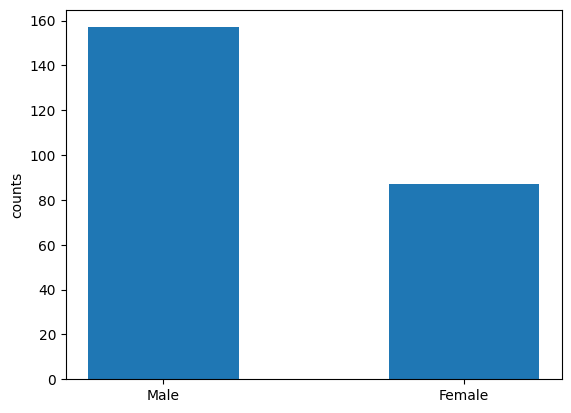

In [65]:
plt.bar(x=gender_counts.index, height=gender_counts.values, width=0.5)
plt.ylabel('counts')
plt.show()

## 가로 막대 그래프(horizontal bar graph)

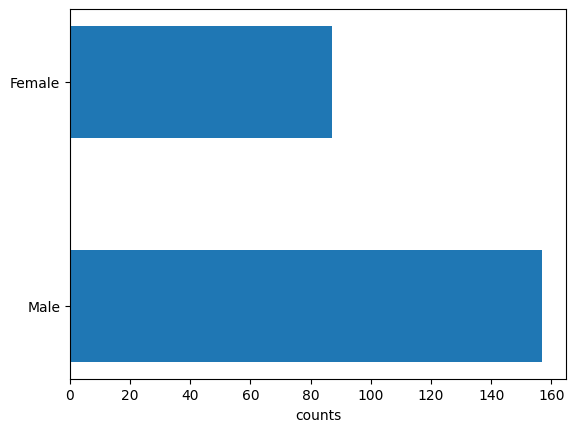

In [68]:
plt.barh(y=gender_counts.index, width=gender_counts.values, height=0.5)
plt.xlabel('counts')
plt.show()

size의 빈도수를 세로 막대 그래프로 표현

In [71]:
size_counts = tips['size'].value_counts()
size_counts

,count
size,
2,156
3,38
4,37
5,5
1,4
6,4


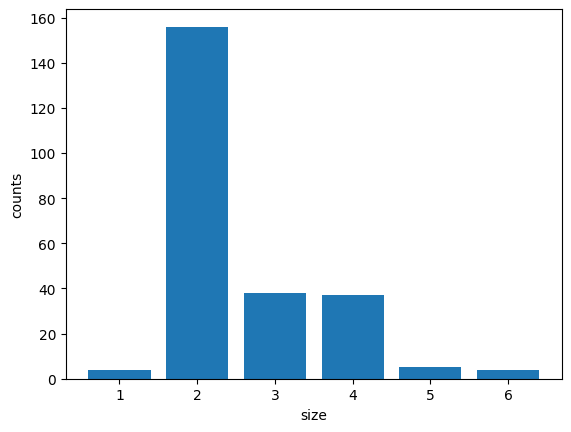

In [73]:
plt.bar(x=size_counts.index, height=size_counts.values)
plt.xlabel('size')
plt.ylabel('counts')
plt.show()

day의 빈도수를 가로 막대 그래프로 표현

In [74]:
day_counts = tips.day.value_counts()
day_counts

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


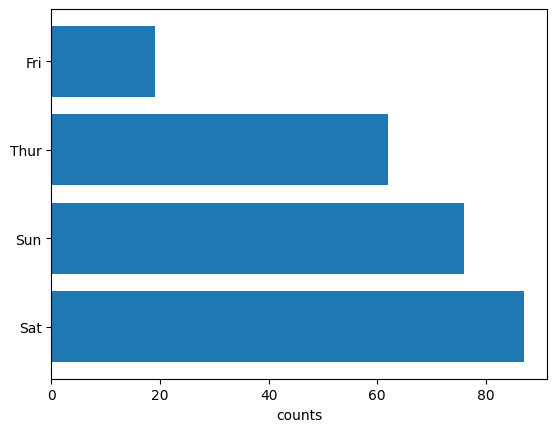

In [76]:
plt.barh(y=day_counts.index, width=day_counts.values)
plt.xlabel('counts')
plt.show()

*   4개의 Axes(Subplots)를 2x2 모양(nrows=2, ncols=2)으로 생성.
*   각각의 Axes에 성별, 흡연여부, 요일, 시간 빈도수를 (세로) 막대 그래프로 시각화.

In [80]:
gender_counts = tips.sex.value_counts()  # tips['sex'].value_counts()
smoker_counts = tips.smoker.value_counts()
day_counts = tips.day.value_counts()
time_counts = tips.time.value_counts()

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


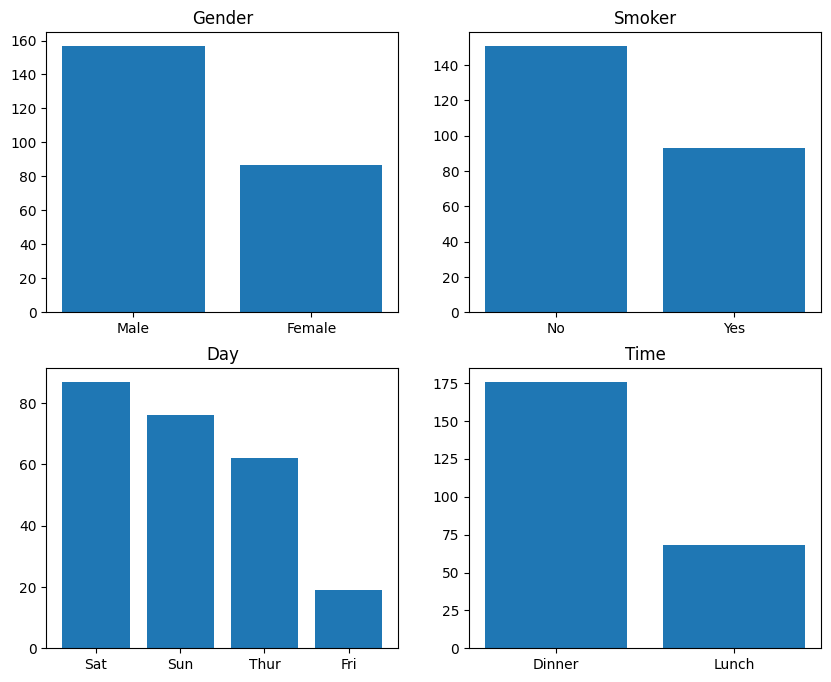

In [92]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
print(axes)  #> axes: 2x2 모양의 2차원 배열

axes[0, 0].bar(x=gender_counts.index, height=gender_counts.values)
axes[0, 1].bar(x=smoker_counts.index, height=smoker_counts.values)
axes[1, 0].bar(x=day_counts.index, height=day_counts.values)
axes[1, 1].bar(x=time_counts.index, height=time_counts.values)

axes[0, 0].set_title('Gender')
axes[0, 1].set_title('Smoker')
axes[1, 0].set_title('Day')
axes[1, 0].set_title('Gender')

plt.show()

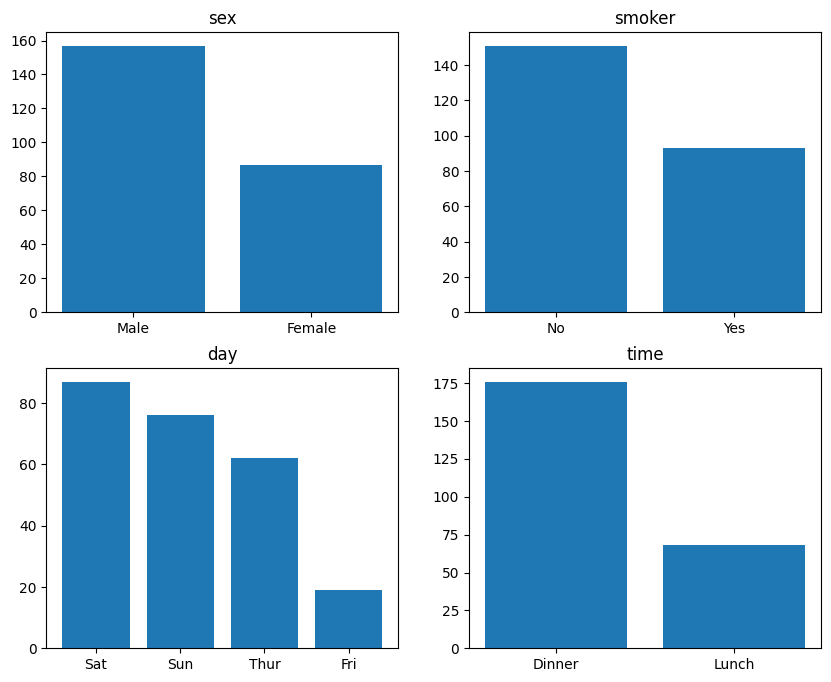

In [96]:
# 막대 그래프를 그리기 위한 변수(컬럼) 이름들
titles = [
    ['sex', 'smoker'],
    ['day', 'time']
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
for i, row in enumerate(titles):
    for j, t in enumerate(row):
        data = tips[t].value_counts()
        axes[i, j].bar(x=data.index, height=data.values)
        axes[i, j].set_title(t)

plt.show()

## 성별 팁 평균 비교

In [101]:
tip_by_gender = tips.groupby(by='sex', observed=True).tip.mean()
tip_by_gender

,tip
sex,
Male,3.089618
Female,2.833448


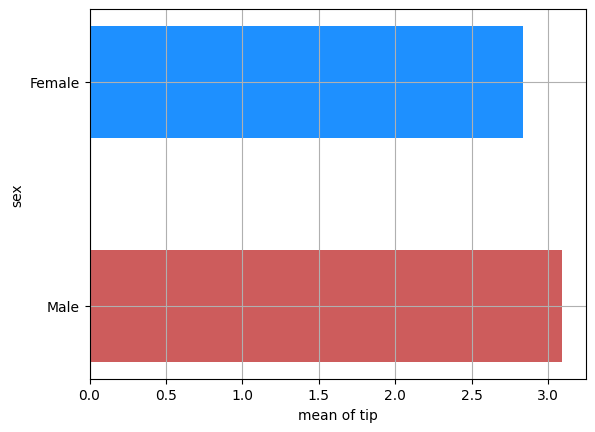

In [107]:
plt.barh(y=tip_by_gender.index, width=tip_by_gender.values, height=0.5,
         color=['IndianRed', 'DodgerBlue'])
plt.ylabel('sex')
plt.xlabel('mean of tip')
plt.grid()
plt.show()

# 산점도(Scatter plot)

*   2개의 연속형 변수 간의 상관 관계를 표현하는 그래프.
*   `y ~ x` 관계 시각화
    *   x: 독립 변수
    *   y: 종속 변수, 관심 변수.

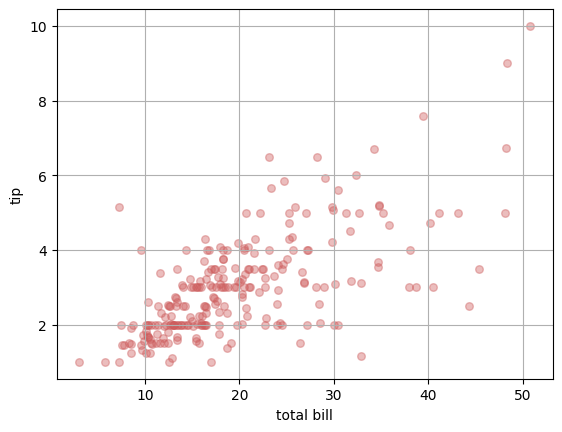

In [124]:
#  tip ~ total_bill 산점도
plt.scatter(
    x=tips.total_bill,  # x: x축에서 사용할 변수(컬럼)
    y=tips.tip,         # y: y축에서 사용할 변수(컬럼)
    c='IndianRed',      # c: color. 마커의 색깔.
    alpha=0.4,          # alpha: 마커의 불투명도(0.0(투명) ~ 1.0(불투명))
    s=30,               # s: size. 마커의 크기.
    marker='o'          # marker: 마커의 모양(o, s, ^, v, *, +, ...).
)
plt.xlabel('total bill')
plt.ylabel('tip')
plt.grid()
plt.show()

In [127]:
tips[['total_bill', 'tip']].corr()  # 상관 계수

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


상관계수(Correlation Coefficient)

*   -1 ~ +1 사이의 값.
*   상관계수 > 0: 양의 상관 관계
*   상관계수 < 0: 음의 상관 관계
*   +1/-1에 가까울 수록 상관 관계가 크다라고 말함.
*   0에 가까울 수록 상관 관계가 작다라고 말함.


*   tip ~ total_bill 산점도
*   성별에 따라서 마커의 색깔을 다르게 표현.

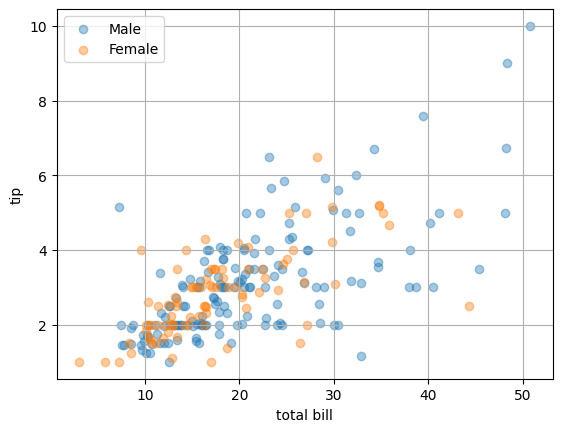

In [141]:
male_df = tips[tips.sex == 'Male']
female_df = tips[tips.sex == 'Female']

plt.scatter(x=male_df.total_bill, y=male_df.tip, alpha=0.4, label='Male')
plt.scatter(x=female_df.total_bill, y=female_df.tip, alpha=0.4, label='Female')

plt.grid()
plt.xlabel('total bill')
plt.ylabel('tip')
plt.legend()  # 범례 표시 - scatter 함수의 label 아규먼트 값을 화면 표시.

plt.show()

*   tip ~ total_bill 산점도
*   성별에 따라서 마커의 색깔을 다르게 표현.
*   흡연여부에 따라서 마커의 모양을 다르게 표현.

In [142]:
tips.sex.cat.categories

Index(['Male', 'Female'], dtype='object')

In [143]:
tips.smoker.cat.categories

Index(['Yes', 'No'], dtype='object')

In [144]:
male_smoker_df = tips[(tips.sex == 'Male') & (tips.smoker == 'Yes')]
male_nonsmoker_df = tips[(tips.sex == 'Male') & (tips.smoker == 'No')]
female_smoker_df = tips[(tips.sex == 'Female') & (tips.smoker == 'Yes')]
female_nonsmoker_df = tips[(tips.sex == 'Female') & (tips.smoker == 'No')]

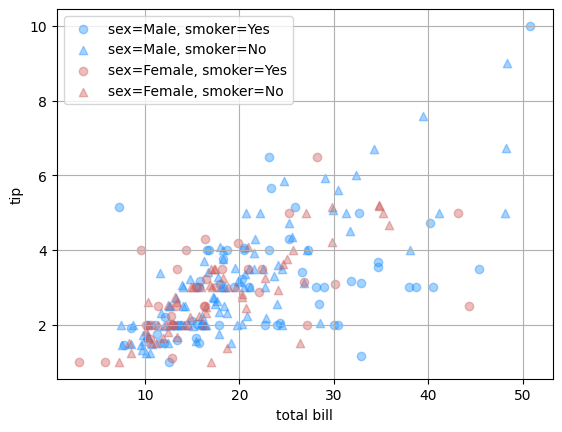

In [152]:
plt.scatter(x=male_smoker_df.total_bill, y=male_smoker_df.tip,
            c='DodgerBlue', marker='o', alpha=0.4,
            label='sex=Male, smoker=Yes')
plt.scatter(x=male_nonsmoker_df.total_bill, y=male_nonsmoker_df.tip,
            c='DodgerBlue', marker='^', alpha=0.4,
            label='sex=Male, smoker=No')
plt.scatter(x=female_smoker_df.total_bill, y=female_smoker_df.tip,
            c='IndianRed', marker='o', alpha=0.4,
            label='sex=Female, smoker=Yes')
plt.scatter(x=female_nonsmoker_df.total_bill, y=female_nonsmoker_df.tip,
            c='IndianRed', marker='^', alpha=0.4,
            label='sex=Female, smoker=No')

plt.legend()
plt.xlabel('total bill')
plt.ylabel('tip')
plt.grid()
plt.show()

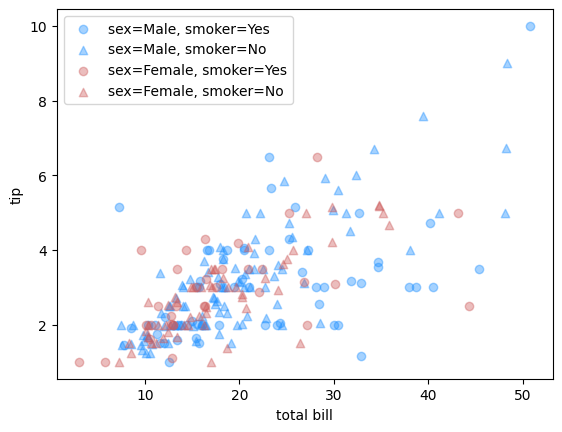

In [158]:
genders = tips.sex.cat.categories  #> ['Male', 'Female']
smokers = tips.smoker.cat.categories  #> ['Yes', 'No']
colors = ['DodgerBlue', 'IndianRed']
markers = ['o', '^']

for g, c in zip(genders, colors):
    for s, m in zip(smokers, markers):
        subset_df = tips[(tips.sex == g) & (tips.smoker == s)]
        plt.scatter(x=subset_df.total_bill, y=subset_df.tip, alpha=0.4,
                    c=c, marker=m, label=f'sex={g}, smoker={s}')

plt.legend()
plt.xlabel('total bill')
plt.ylabel('tip')
plt.show()

*   1개의 Figure에 상/하 2개의 Axes를 생성.
*   위쪽 Axes에는 total_bill 변수의 히스토그램을 표현.
*   아래쪽 Axes에는 tip ~ total_bill 산점도를 표현.

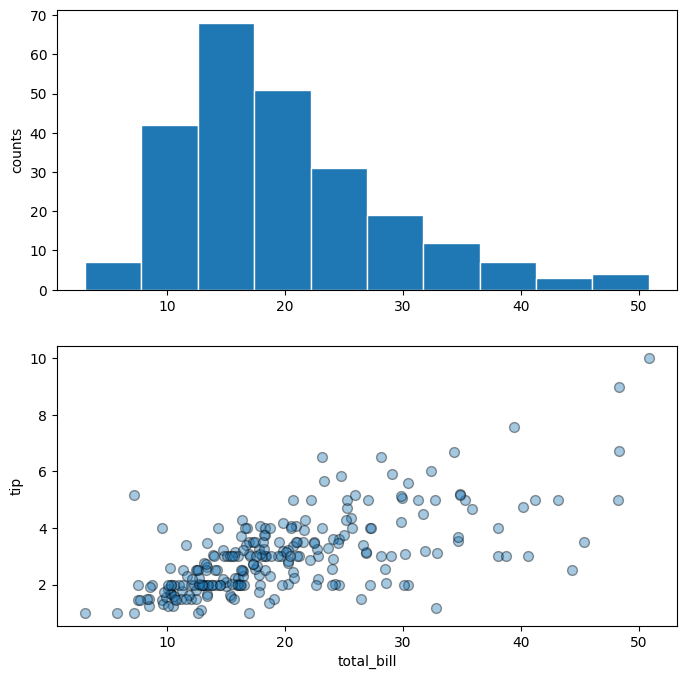

In [172]:
fig, axes = plt.subplots(nrows=2, figsize=(8, 8))

axes[0].hist(x=tips.total_bill, edgecolor='white')
axes[1].scatter(x=tips.total_bill, y=tips.tip, alpha=0.4, edgecolor='black', s=50)

axes[0].set_ylabel('counts')
axes[1].set_ylabel('tip')
axes[1].set_xlabel('total_bill')

plt.show()

#  선 그래프(Line plot)

주로 시계열 데이터(주식, 환율, 부동산 가격, 미세먼지 농도, 지지도 변화, ...)를 시각화.

In [174]:
# 선 그래프에서 사용할 가상의 데이터
np.random.seed(1)  # 실행할 때마다 같은 난수들이 만들어지도록 하기 위해서.
df = pd.DataFrame(data={
    'day': np.arange(1, 11),
    'price': np.random.rand(10),
})
df

,day,price
0,1,0.417022
1,2,0.720324
2,3,0.000114
3,4,0.302333
4,5,0.146756
5,6,0.092339
6,7,0.186260
7,8,0.345561
8,9,0.396767
9,10,0.538817


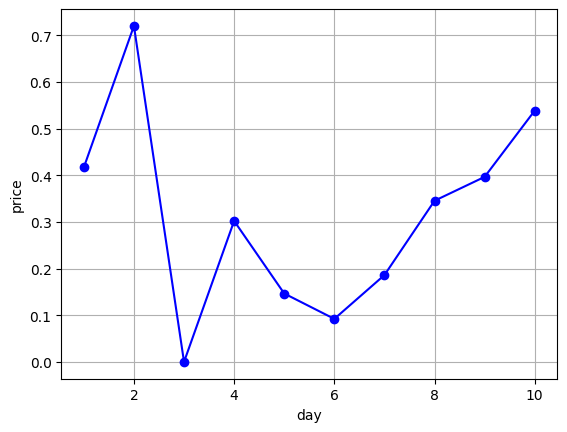

In [200]:
plt.plot(df.day, df.price, 'bo-')
plt.xlabel('day')
plt.ylabel('price')
plt.grid()
plt.show()

`plt.plot([x], y, [fmt])`

*   x: x좌표로 사용할 변수(컬럼). 생략 가능. 생략하면 y의 인덱스가 x좌표로 사용됨.
*   y: y좌표로 사용할 변수. 필수.
*   fmt: 포맷 문자열. color(마커와 선의 색깔), marker(마커 모양), linestyle(선 스타일) 정보를 문자열로 표현. 생략 가능. 생략하면 마커 없이 직서으로 표시.
    *   color: r(red), g(green), b(blue), k(black), ...
    *   marker: o, s, ^, ...
    *   linestyle: -(solid line, 직선), --(dashed line), :(dotted line, 점선), ...
    *   (예) 'ro-': red, circle, solid line
    *   fmt 문자열 대신에 **kwargs를 사용해도 됨.
    *   선 스타일(linestyle)이 없는 경우, 산점도(scatter)와 같아짐.

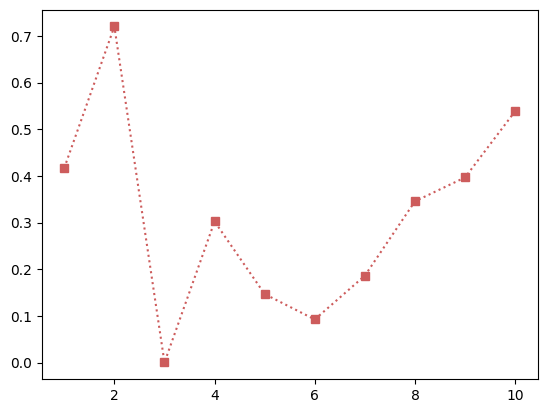

In [212]:
plt.plot(df.day, df.price, color='IndianRed', marker='s', linestyle=':')
plt.show()

In [213]:
np.random.seed(42)
df2 = pd.DataFrame(data={
    'day': np.arange(1, 16),
    'hynix': np.random.rand(15),
    'samsung': np.random.rand(15),
    'nvidia': np.random.rand(15),
})
df2

,day,hynix,samsung,nvidia
0,1,0.374540,0.183405,0.607545
1,2,0.950714,0.304242,0.170524
2,3,0.731994,0.524756,0.065052
3,4,0.598658,0.431945,0.948886
4,5,0.156019,0.291229,0.965632
5,6,0.155995,0.611853,0.808397
6,7,0.058084,0.139494,0.304614
7,8,0.866176,0.292145,0.097672
8,9,0.601115,0.366362,0.684233
9,10,0.708073,0.456070,0.440152


*   위의 데이터프레임 df2에서 samsung, hynix, nvidia 데이터를 선 그래프로 시각화.
*   데이터마다 마커 모양, 색깔, 선 스타일을 모두 다르게 표현.
*   범례 표시.

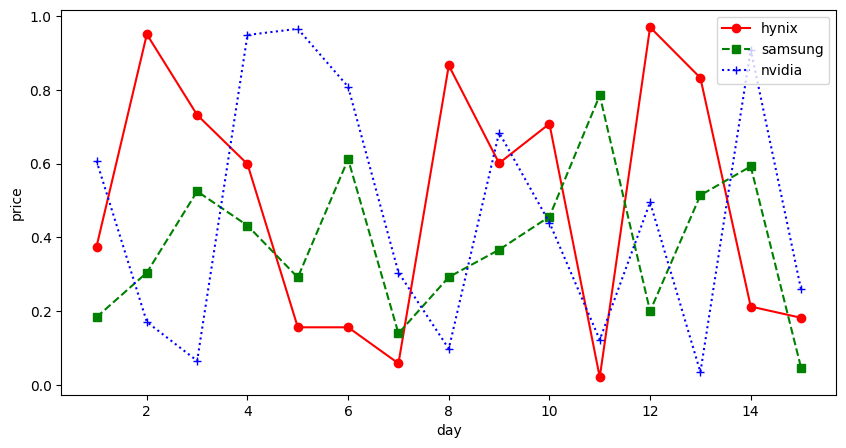

In [220]:
plt.figure(figsize=(10, 5))

plt.plot(df2.day, df2.hynix, 'ro-', label='hynix')
plt.plot(df2.day, df2.samsung, 'gs--', label='samsung')
plt.plot(df2.day, df2.nvidia, 'b+:', label='nvidia')

plt.legend()
plt.xlabel('day')
plt.ylabel('price')
plt.show()